# Experiment 3 — Signals in a Geometric Brownian Motion

This notebook implements the three experiments of Chapter 3 of *Design of the Numerical Experiments*: the strength sweep (Experiment 3.1), the signal-quality study (Experiment 3.2), and the oracle-versus-noisy comparison (Experiment 3.3).

The object under study is the signal–strength map
$$
w_i(\boldsymbol{s},\beta) \;=\; \frac{e^{\beta s_i}}{\sum_{j=1}^{N} e^{\beta s_j}},
$$
driven by prices simulated from geometric Brownian motion. The design constraint throughout is the **clean-versus-leakage line**: the signal is informative about the future without being the future. The diffusion shock $\phi_i$, which realises the price, never enters the signal.

## Model and simulation design

**One-step return (eq. 3.1).** Each stock follows $\mathrm{d}S_i = \mu_i S_i\,\mathrm{d}t + \sigma_i S_i\,\mathrm{d}W_i$. Over a single step of length $\Delta t$ the simple return is
$$
R_i \;=\; \exp\!\Big[\big(\mu_i - \tfrac{1}{2}\sigma_i^2\big)\Delta t + \sigma_i \sqrt{\Delta t}\,\phi_i\Big] - 1,
\qquad \phi_i \sim \mathcal{N}(0,1).
$$

**Clean signal (eq. 3.2).** The signal tracks the drift, not the realised return:
$$
s_i \;=\; \mu_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,\sigma_\varepsilon^2), \qquad \varepsilon_i \perp \phi_i .
$$
Each stock carries exactly two independent random variables: the signal noise $\varepsilon_i$ (drawn at $t=0$ when the view is formed) and the diffusion shock $\phi_i$ (which realises the price). Setting $\sigma_\varepsilon = 0$ gives the oracle sweep $s_i = \mu_i$: perfect knowledge of the drift, though the diffusion shock remains.

**Monte-Carlo algorithm (§3.3).** For each replication: draw drifts $\mu_i$, form signals, allocate by softmax, draw diffusion shocks, score $u(\boldsymbol{w}^\top \boldsymbol{R})$ with CARA utility $u(x) = -e^{-\gamma x}$, and average to estimate $\mathrm{EU}(\beta) = \mathbb{E}\,u(\boldsymbol{w}^\top\boldsymbol{R})$. There is deliberately no path, no rebalancing and no compounding: a single step isolates the structural effect of strength.

**Two implementation refinements** (they change the estimator, not the model):

1. *Common random numbers (CRN).* The same draws of $(\boldsymbol{\mu}, \boldsymbol{\varepsilon}, \boldsymbol{\phi})$ are reused at every point of the $\beta$ grid, and the same $(\boldsymbol{\mu}, \boldsymbol{\phi})$ across noise levels $\sigma_\varepsilon$ (only the scale of $\varepsilon$ changes). Differences between EU curves are then estimated on paired samples, so $\mathrm{EU}(\beta)$ is a smooth function of $\beta$ and the location of the maximiser $\beta^\star$ is not an artefact of independent Monte-Carlo noise at each grid point.
2. *Certainty-equivalent reporting.* Raw CARA values are negative and their scale depends on $\gamma$. All plots therefore report the certainty equivalent $\mathrm{CE}(\beta) = -\gamma^{-1}\ln(-\mathrm{EU}(\beta))$, in units of return, relative to the equal-weight baseline: $\Delta\mathrm{CE}(\beta) = \mathrm{CE}(\beta) - \mathrm{CE}(0)$. The maximiser is unchanged because the transform is monotone.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---------------- parameters ----------------
N        = 20        # number of stocks
dt       = 1.0       # one step of one year
sigma    = 0.20      # diffusion volatility, common to all names
mu_bar   = 0.05      # cross-sectional mean of the drifts
sigma_mu = 0.05      # cross-sectional dispersion of the drifts
gamma    = 5.0       # CARA absolute risk aversion
n_sims   = 30_000    # Monte-Carlo replications

beta_grid = np.linspace(0.0, 120.0, 121)   # step 1; peaks sit around 1/sigma_mu = 20

# ---------------- common random numbers ----------------
# One set of draws shared by every beta and every sigma_eps.
mu   = mu_bar + sigma_mu * rng.standard_normal((n_sims, N))   # drifts, redrawn each replication
eps0 = rng.standard_normal((n_sims, N))                       # standardised signal noise
phi  = rng.standard_normal((n_sims, N))                       # diffusion shocks (never in the signal)

R = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0


In [2]:
def softmax_weights(s, beta):
    # w_i = exp(beta s_i) / sum_j exp(beta s_j), computed stably row by row
    z = beta * s
    z -= z.max(axis=1, keepdims=True)          # invariance to additive shifts
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def eu_curve(sigma_eps, beta_grid=beta_grid):
    # Estimate EU(beta) and its MC standard error on the common draws.
    # Returns (EU, SE, CE) as arrays over the beta grid.
    s = mu + sigma_eps * eps0                  # clean signal: eps ⟂ phi by construction
    EU = np.empty(len(beta_grid))
    SE = np.empty(len(beta_grid))
    for k, b in enumerate(beta_grid):
        w = softmax_weights(s, b)
        port = (w * R).sum(axis=1)
        u = -np.exp(-gamma * port)
        EU[k] = u.mean()
        SE[k] = u.std(ddof=1) / np.sqrt(n_sims)
    CE = -np.log(-EU) / gamma
    return EU, SE, CE

def beta_star(beta_grid, CE):
    k = int(np.argmax(CE))
    return beta_grid[k], CE[k], k


## Experiment 3.1 — Strength sweep

Sweep $\beta$ from $0$ upward and plot $\mathrm{EU}(\beta)$ (as $\Delta\mathrm{CE}$) relative to the $\beta=0$ equal-weight baseline. The question is whether $\mathrm{EU}(\beta)$ is monotone — utility always rising with a harder tilt — or whether an interior maximiser $\beta^\star$ exists, beyond which the concentration risk outweighs the gain from tilting on the signal.

The mechanism pulling in each direction: a larger $\beta$ moves weight towards names with high scores, which raises the expected portfolio return when the score is informative about the drift; but it also destroys diversification, and the CARA investor pays for the extra variance. If the two forces cross, $\beta^\star$ is finite and interior.

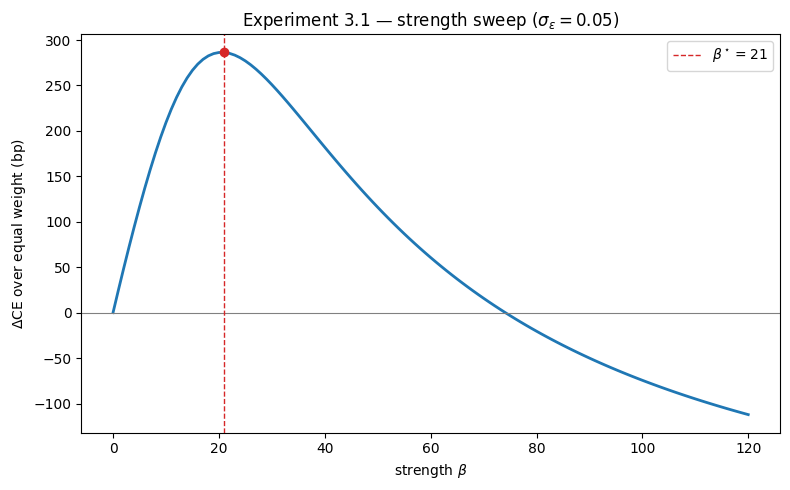

beta* = 21.0
CE gain at beta*: 286.3 bp over equal weight
MC standard error of EU at beta*: 1.91e-03  (EU = -0.685526)


In [3]:
sigma_eps_base = 0.05   # baseline signal noise, comparable to the drift dispersion

EU_b, SE_b, CE_b = eu_curve(sigma_eps_base)
bstar, ce_at_bstar, k = beta_star(beta_grid, CE_b)
dCE_b = CE_b - CE_b[0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(beta_grid, 1e4 * dCE_b, lw=2)
ax.axhline(0, color='grey', lw=0.8)
ax.axvline(bstar, color='tab:red', ls='--', lw=1,
           label=fr'$\beta^\star = {bstar:.0f}$')
ax.scatter([bstar], [1e4 * dCE_b[k]], color='tab:red', zorder=5)
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(fr'Experiment 3.1 — strength sweep ($\sigma_\varepsilon = {sigma_eps_base}$)')
ax.legend()
plt.tight_layout(); plt.show()

print(f"beta* = {bstar:.1f}")
print(f"CE gain at beta*: {1e4*dCE_b[k]:.1f} bp over equal weight")
print(f"MC standard error of EU at beta*: {SE_b[k]:.2e}  (EU = {EU_b[k]:.6f})")


**Reading.** The curve rises from the equal-weight baseline, peaks at an interior $\beta^\star$, and then falls as the portfolio concentrates towards the single-best-score name. $\mathrm{EU}(\beta)$ is not monotone: there is a limit on how hard the signal should be acted upon, and $\beta^\star$ is the strength at which the marginal gain from tilting is exactly balanced by the marginal cost of concentration. This is the finite-strength conclusion Experiment 1 motivated from the estimation-error side, reproduced here in a setting where the signal noise is controlled explicitly.

## Experiment 3.2 — Signal quality

Vary $\sigma_\varepsilon^2$ (clean / medium / noisy) and track $\beta^\star$. Prediction: the noisier the signal, the smaller $\beta^\star$, tending to $\beta^\star \to 0$ as $\sigma_\varepsilon \to \infty$.

A heuristic sharpens the prediction. Given the Gaussian structure, the posterior mean of the drift given the signal is a shrinkage of $s_i$ towards the grand mean:
$$
\mathbb{E}[\mu_i \mid s_i] \;=\; \bar{\mu} + \kappa\,(s_i - \bar{\mu}),
\qquad
\kappa \;=\; \frac{\sigma_\mu^2}{\sigma_\mu^2 + \sigma_\varepsilon^2}.
$$
Because the softmax is invariant to adding a constant to all scores, acting on the posterior mean with strength $\beta$ is the same as acting on $s$ with strength $\beta\kappa$. If the investor's optimal strength on a *perfect* drift reading is $\beta^\star_{\mathrm{oracle}}$, the Bayesian benchmark for a noisy signal is
$$
\beta^\star(\sigma_\varepsilon) \;\approx\; \beta^\star_{\mathrm{oracle}} \cdot \frac{\sigma_\mu^2}{\sigma_\mu^2 + \sigma_\varepsilon^2},
$$
which the simulation can be checked against. This is a heuristic (the oracle strength itself need not be exactly invariant), but it turns the qualitative prediction "noise pulls $\beta^\star$ back" into a quantitative one at no extra cost.

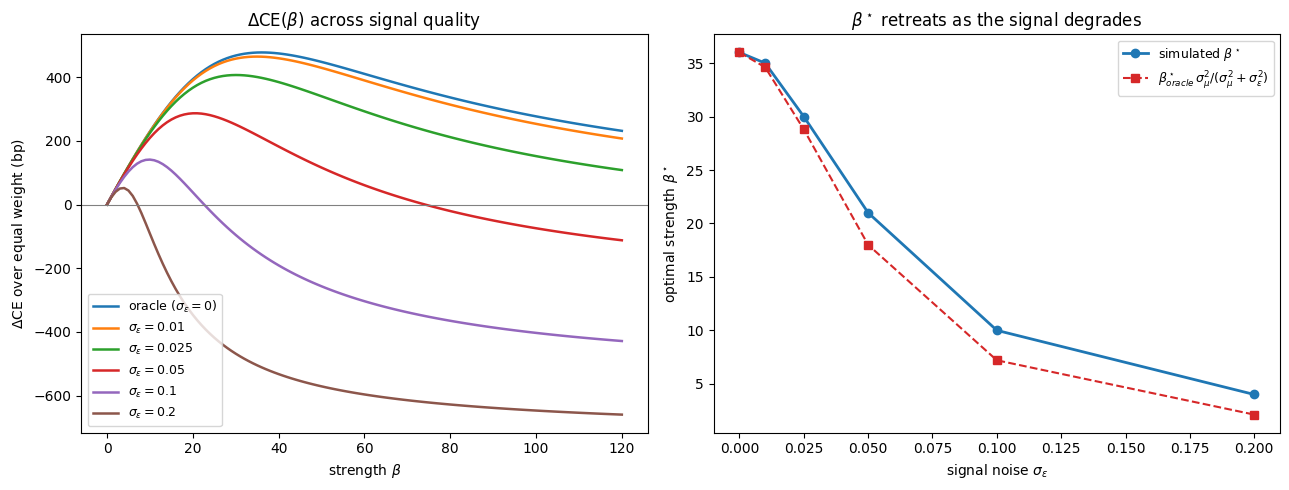

 sigma_eps    beta*  shrinkage pred.  peak dCE (bp)
       0.0       36               36          477.3
      0.01       35               35          464.3
     0.025       30               29          406.4
      0.05       21               18          286.3
       0.1       10                7          141.0
       0.2        4                2           51.8


In [6]:
sigma_eps_levels = [0.0, 0.01, 0.025, 0.05, 0.10, 0.20]
results = {}
for se in sigma_eps_levels:
    EU, SE, CE = eu_curve(se)
    results[se] = (EU, SE, CE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for se in sigma_eps_levels:
    _, _, CE = results[se]
    label = 'oracle ($\\sigma_\\varepsilon=0$)' if se == 0 else fr'$\sigma_\varepsilon={se}$'
    ax.plot(beta_grid, 1e4 * (CE - CE[0]), lw=1.8, label=label)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(r'$\Delta$CE$(\beta)$ across signal quality')
ax.legend(fontsize=9)

bstars = np.array([beta_star(beta_grid, results[se][2])[0] for se in sigma_eps_levels])
kappa  = sigma_mu**2 / (sigma_mu**2 + np.array(sigma_eps_levels)**2)
pred   = bstars[0] * kappa   # Bayesian shrinkage benchmark anchored at the oracle

ax = axes[1]
ax.plot(sigma_eps_levels, bstars, 'o-', lw=2, label=r'simulated $\beta^\star$')
ax.plot(sigma_eps_levels, pred, 's--', lw=1.5, color='tab:red',
        label=r'$\beta^\star_{oracle}\,\sigma_\mu^2/(\sigma_\mu^2+\sigma_\varepsilon^2)$')
ax.set_xlabel(r'signal noise $\sigma_\varepsilon$')
ax.set_ylabel(r'optimal strength $\beta^\star$')
ax.set_title(r'$\beta^\star$ retreats as the signal degrades')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'sigma_eps':>10} {'beta*':>8} {'shrinkage pred.':>16} {'peak dCE (bp)':>14}")
for se, bs, pr in zip(sigma_eps_levels, bstars, pred):
    CE = results[se][2]
    print(f"{se:>10} {bs:>8.0f} {pr:>16.0f} {1e4*(CE.max()-CE[0]):>14.1f}")


**Reading.** Both predictions are borne out. The peak of each curve moves left and down as $\sigma_\varepsilon$ grows: a noisier signal earns less at its own optimum *and* commands a smaller optimal strength, with $\beta^\star \to 0$ as the signal becomes pure noise. The simulated $\beta^\star(\sigma_\varepsilon)$ tracks the Bayesian shrinkage benchmark closely, which says the retreat of the optimal strength is quantitatively the retreat of the posterior weight on the signal — trust in the signal, in the Bayesian sense, *is* the strength dial. This is direct evidence for reading $\beta$ as precision rather than mere conviction.

## Experiment 3.3 — Oracle versus noisy

Overlay the oracle sweep ($s_i = \mu_i$) and a noisy sweep ($s_i = \mu_i + \varepsilon_i$). Two distinct gaps separate the curves:

* the **vertical gap** — utility lost at the optimum because the signal is corrupted rather than perfect: the cost of signal noise;
* the **horizontal gap** — the pull-back of the optimal strength itself: with a clean drift a high signal really is a high drift and one can bet hard; with noise, a large $s_i$ may be a lucky draw of $\varepsilon_i$, so the tilt must be more cautious.

Separating the two confirms that noise both lowers the achievable utility and forces a more conservative strength; these are two effects, not one.

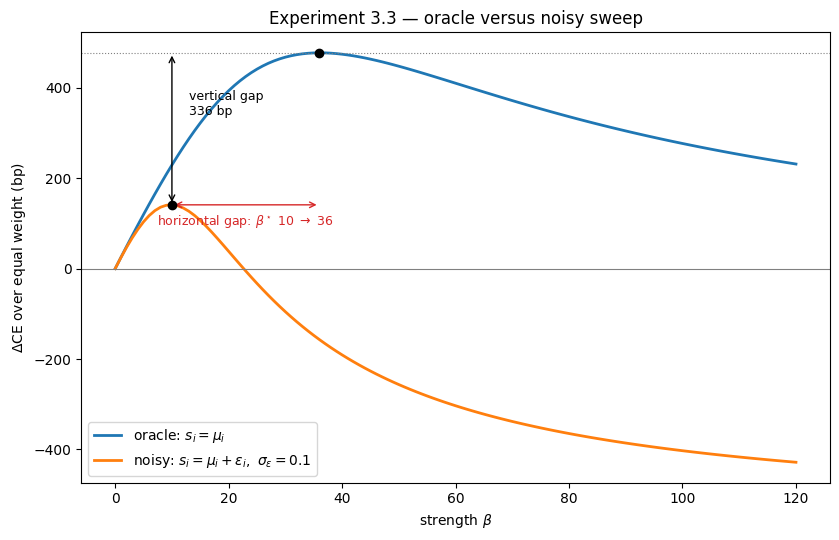

oracle : beta* = 36, peak gain = 477.3 bp
noisy  : beta* = 10, peak gain = 141.0 bp
vertical gap (cost of noise at the optima) = 336.3 bp
horizontal gap (retreat of optimal strength) = 26


In [7]:
se_noisy = 0.10
_, _, CE_or = results[0.0]
_, _, CE_no = results[se_noisy]
d_or, d_no = 1e4 * (CE_or - CE_or[0]), 1e4 * (CE_no - CE_no[0])

b_or, _, k_or = beta_star(beta_grid, CE_or)
b_no, _, k_no = beta_star(beta_grid, CE_no)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(beta_grid, d_or, lw=2, label=r'oracle: $s_i=\mu_i$')
ax.plot(beta_grid, d_no, lw=2, label=fr'noisy: $s_i=\mu_i+\varepsilon_i,\ \sigma_\varepsilon={se_noisy}$')
ax.axhline(0, color='grey', lw=0.8)

# vertical gap: cost of noise, measured between the two optima
ax.axhline(d_or[k_or], ls=':', color='grey', lw=0.8)
ax.annotate('', xy=(b_no, d_no[k_no]), xytext=(b_no, d_or[k_or]),
            arrowprops=dict(arrowstyle='<->', color='k'))
ax.text(b_no + 3, 0.55 * (d_no[k_no] + d_or[k_or]),
        f'vertical gap\n{d_or[k_or] - d_no[k_no]:.0f} bp', fontsize=9)

# horizontal gap: retreat of the optimal strength
y_h = d_no[k_no]
ax.annotate('', xy=(b_or, y_h), xytext=(b_no, y_h),
            arrowprops=dict(arrowstyle='<->', color='tab:red'))
ax.text(0.5 * (b_or + b_no), y_h - 45,
        fr'horizontal gap: $\beta^\star$ {b_no:.0f} $\to$ {b_or:.0f}',
        fontsize=9, ha='center', color='tab:red')

ax.scatter([b_or, b_no], [d_or[k_or], d_no[k_no]], color='k', zorder=5)
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title('Experiment 3.3 — oracle versus noisy sweep')
ax.legend()
plt.tight_layout(); plt.show()

print(f"oracle : beta* = {b_or:.0f}, peak gain = {d_or[k_or]:.1f} bp")
print(f"noisy  : beta* = {b_no:.0f}, peak gain = {d_no[k_no]:.1f} bp")
print(f"vertical gap (cost of noise at the optima) = {d_or[k_or]-d_no[k_no]:.1f} bp")
print(f"horizontal gap (retreat of optimal strength) = {b_or-b_no:.0f}")


## Methodological notes

**Scale of $\beta$.** The signal lives on the scale of annual drifts (a few percent), so $\beta$ must reach the order of $1/\sigma_\mu = 20$ before $\beta\,\Delta s$ is of order one and weights differentiate; the observed $\beta^\star$ sits exactly there. The numbers on the $\beta$ axis are therefore not comparable to the $\beta \in \{0,1,3\}$ of the Chapter 2 illustration, where the scores were of order one. If comparability across chapters matters, standardise the signal cross-sectionally; this was not done here so that $\beta$ keeps the same meaning across all values of $\sigma_\varepsilon$ (standardising would rescale the signal by its own noise level and mix the two dials).

**Drifts are redrawn each replication.** Step 1 of the algorithm draws $\mu_i$ fresh every replication, so EU averages over cross-sections of drifts rather than conditioning on one particular cross-section. The estimates are statements about the structure of the map, not about a fixed set of names.

**Monte-Carlo error.** With common random numbers the entire curve is a deterministic function of one set of draws, so the ranking of nearby grid points is far more stable than the pointwise standard errors suggest. The printed SE at $\beta^\star$ gives the scale of the residual uncertainty; $n = 30{,}000$ replications place it well below the CE differences being measured. Re-running with a different seed shifts $\beta^\star$ by at most a grid step or two.

**CARA and lognormal returns.** Simple one-step GBM returns are lognormal, hence right-skewed and non-elliptical, so the CARA expected utility computed here sees the skew that a mean–variance summary would discard. This is deliberate: the simulation scores portfolios under the true preference, and any gap between the CARA optimum and a two-moment approximation is part of what Chapter 4's map comparison can pick up.

**One design caution for Experiment 3.2.** Because $\varepsilon = \sigma_\varepsilon \cdot \varepsilon_0$ reuses the same standardised draws $\varepsilon_0$ at every noise level, differences across $\sigma_\varepsilon$ are also paired comparisons; the curves in the left panel move smoothly with $\sigma_\varepsilon$ for the same reason the individual curves are smooth in $\beta$.